# Customer Churn and Retention Analysis

This project focuses on analyzing **customer churn** in the Telco dataset.  
Churn refers to customers who leave the company, and predicting churn helps businesses take action to **retain valuable customers**.  

We will use a combination of:
- **SQL** (for data exploration and summarization),
- **Python** (for preprocessing, feature engineering, and building machine learning models), and
- **Power BI** (for creating interactive dashboards and insights).

The dataset contains information on customer demographics, services subscribed, account details, and whether the customer has churned.  
Our main goals in this project are:
1. Explore churn patterns using SQL queries.  
2. Preprocess and build predictive models (Logistic Regression, Random Forest, and XGBoost) using Python.  
3. Evaluate model performance with metrics like Accuracy, ROC-AUC, and Confusion Matrix.  
4. Export predictions and aggregated insights to Power BI for visualization.  

This end-to-end project demonstrates **real-world data analytics workflow** combining data engineering, machine learning, and business intelligence tools.

---

### Install Required Libraries

Before connecting Python to MySQL, we need to install additional libraries:
- **SQLAlchemy** → helps Python connect to SQL databases.
- **PyMySQL** → a driver that allows Python to talk to MySQL.

The command below will install both packages.

In [1]:
# Install required libraries for MySQL connection
!pip install sqlalchemy pymysql

#### <u>Code Description</u> 
The command uses `pip` (Python’s package installer) to install two libraries:  
- `sqlalchemy`: provides a toolkit for database connections and queries.  
- `pymysql`: acts as a connector that enables Python to communicate with a MySQL database.  

These libraries are essential for loading SQL data into Python using pandas.

---

### Connect to MySQL Database

We now set up the connection details required to connect Python with our MySQL database.  
This includes:
- Username and password  
- Host (server address)  
- Database name  

We also encode the password to handle any special characters.

In [2]:
# Import required libraries
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# Define MySQL connection details
user = 'root'                         # MySQL username
password = 'Guzzlord@13579'           # MySQL password
password_encoded = quote_plus(password)  # Encode password in case of special characters
host = 'localhost'                    # Server location (localhost = this machine)
database = 'telco_churn'              # Database name to connect to

#### <u>Code Description</u>  
1. **pandas** is imported for data handling.  
2. **sqlalchemy** provides tools for connecting to the MySQL database.  
3. **quote_plus** is used to encode the password safely (important if it contains special characters like `@`, `!`, etc.).  
4. Variables are defined for the MySQL login:  
   - `user`: database username  
   - `password`: database password (encoded into `password_encoded`)  
   - `host`: database server address  
   - `database`: the name of the database we want to work with (`telco_churn`).  
---

### Load Data from MySQL into Pandas

In this step, we:  
1. Create a connection string using SQLAlchemy to connect Python with MySQL.  
2. Write an SQL query to fetch all records from the `customers` table.  
3. Load the query result directly into a pandas DataFrame (`df`) for further analysis.  


In [3]:
# Create the connection string using pymysql driver
engine = create_engine(f'mysql+pymysql://{user}:{password_encoded}@{host}/{database}')

# Define SQL query to fetch all data from the 'customers' table
query = "SELECT * FROM customers;"

# Execute the query and load results into a pandas DataFrame
df = pd.read_sql(query, engine)

#### <u>Code Description</u>  
1. **`create_engine()`**: Builds a connection to the MySQL database using the provided credentials.  
   - `mysql+pymysql://` specifies the database type and driver.  
   - `{user}:{password_encoded}@{host}/{database}` fills in the login details.  
2. **SQL query**: `"SELECT * FROM customers;"` retrieves all rows and columns from the `customers` table.  
3. **`pd.read_sql()`**: Runs the SQL query through the engine and stores the results in a pandas DataFrame called `df`.  

This gives us direct access to the database table within Python.  

---

### Previewing the Dataset

- To understand the structure of the loaded data, we display the first 5 rows of the DataFrame using `df.head()`.  
- This helps verify that the data has been imported correctly and provides an initial look at the available columns and sample values.  


In [4]:
# Display the first 5 rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services
0,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,Yes,No,One year,Yes,Mailed check,65.6,593.30,No,0-12 Months,5
1,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,No,0-12 Months,4
2,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes,0-12 Months,3
3,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes,13-24 Months,6
4,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,Yes,0-12 Months,4


#### <u>Code Description</u>  
- **`df.head()`**: By default, shows the first 5 rows of the DataFrame.  
- It allows us to quickly inspect column names, data types, and some example entries before proceeding with further analysis.  

#### <u>Output Description</u>  
The output shows the first 5 customers from the dataset with all the features. Key details include:  
- **customerID**: Unique identifier for each customer.  
- **Demographics**: `gender`, `SeniorCitizen`, `Partner`, `Dependents`.  
- **Services**: `PhoneService`, `MultipleLines`, `InternetService`, etc.  
- **Billing**: `Contract`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`.  
- **Target Variable**: `Churn` indicates whether the customer left (Yes) or stayed (No).  

This confirms the dataset has been successfully imported and is ready for preprocessing.  

---

## Exploratory Data Analysis (EDA)

### Checking the Shape of the Dataset

Before diving deeper, it’s important to know how many records and features the dataset contains.  
This helps confirm that the data has been imported completely and matches expectations.  

In [5]:
# Shape of dataset
print("Number of rows and columns:", df.shape)

Number of rows and columns: (7032, 23)


#### <u>Code Description</u>  
- **`df.shape`**: Returns a tuple representing the number of rows and columns in the DataFrame.  
- **`print()`**: Displays this information in a readable format.  
- Helps quickly understand the dataset size.  

#### <u>Output Description</u>  
- The dataset contains **7032 rows** (customers) and **23 columns** (features).  
- This confirms that the full dataset has been loaded and all columns are present for further analysis.  

---

### Checking Column Names and Data Types

Understanding the data types of each column helps in planning preprocessing steps,  
like encoding categorical variables, scaling numerical features, or handling missing values.

In [6]:
# Column names and data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


#### <u>Code Description</u>  
- **`df.info()`**: Displays detailed information about the DataFrame including:  
  - Number of entries (rows)  
  - Column names  
  - Non-null counts for each column  
  - Data type (`dtype`) of each column  
- Useful for identifying categorical vs numerical columns and checking for missing values.

#### <u>Output Description</u>  
- The dataset has **7032 entries** and **23 columns**.  
- Data types:  
  - 18 columns are **object** (categorical/string).  
  - 3 columns are **int64** (numerical integers).  
  - 2 columns are **float64** (numerical decimals).  
- No missing values in any column, which means the dataset is complete.  
- Helps in deciding which columns need encoding or preprocessing before modeling.

---

### Checking for Missing Values

Before modeling, it's important to check if any column has missing values.  
Missing values may require imputation or removal to avoid errors during training.


In [7]:
# Check for missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
tenure_group        0
total_services      0
dtype: int64

#### <u>Code Description</u>  
- **`df.isnull().sum()`**: Checks each column for null/missing values and sums them up.  
- Returns the count of missing values per column.  
- Helps ensure the dataset is clean before further preprocessing or model training.

#### <u>Output Description</u>  
- All columns have **0 missing values**, confirming that the dataset is complete.  
- No further imputation is needed for any feature.  
- This allows us to move directly to preprocessing and encoding categorical variables.

---

### Visualizing Target Variable: Churn

Before building models, it's important to understand the distribution of the target variable. Here, we visualize the count of customers who churned vs. those who did not.

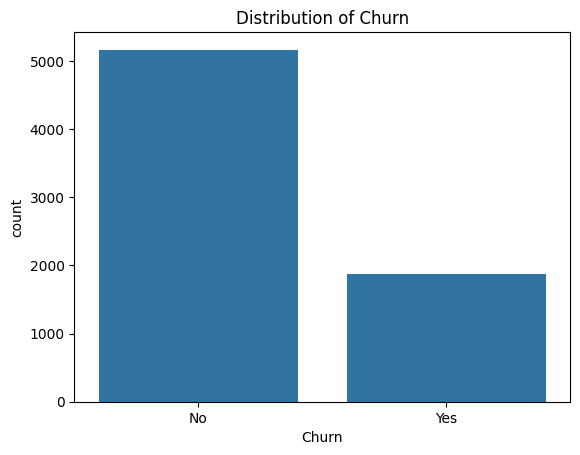

No     73.421502
Yes    26.578498
Name: Churn, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot for Churn
sns.countplot(x='Churn', data=df)
plt.title("Distribution of Churn")
plt.show()

# Percentage of churn vs no churn
print(df['Churn'].value_counts(normalize=True)*100)

#### <u>Code Description</u>  
- **`sns.countplot`**: Plots the count of each category in the `Churn` column.  
- **`plt.title`**: Adds a title to the plot.  
- **`df['Churn'].value_counts(normalize=True)*100`**: Calculates the percentage of each class (Yes/No) in the target variable.  
- Helps in understanding class balance before modeling.

#### <u>Output Description</u>  
- The bar plot shows **more customers did not churn** (No) compared to those who churned (Yes).  
- Percentages:  
  - No: 73.42%  
  - Yes: 26.58%  
- Indicates a **class imbalance**, which may need to be considered during model training or evaluation.
---

### Exploring Numeric Features

We visualize the distribution of key numeric features to understand their spread and concentration.

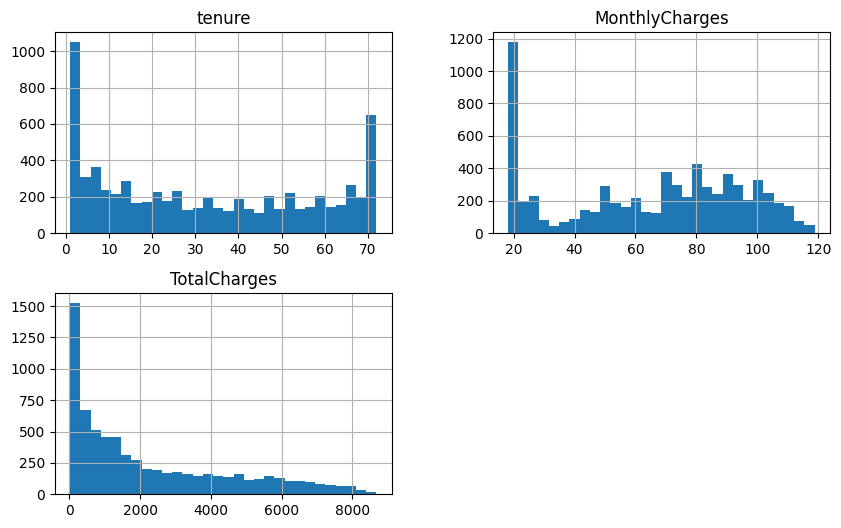

In [9]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Histograms
df[numeric_cols].hist(bins=30, figsize=(10,6))
plt.show()

#### <u>Code Description</u>  
- **`df[numeric_cols].hist`**: Plots histograms for selected numeric columns.  
- **`bins=30`**: Divides the data range into 30 intervals for the histogram.  
- **`figsize=(10,6)`**: Sets the size of the figure for better visibility.  
- Helps identify the distribution, skewness, and possible outliers in numeric variables.

#### <u>Output Description</u>  
- **`tenure`**: Most customers have tenure between 0-20 months and 50-70 months.  
- **`MonthlyCharges`**: Concentration around 20-120 range, slightly right-skewed.  
- **`TotalCharges`**: Right-skewed distribution; most values are at the lower end but some customers have very high total charges.  
- These distributions provide insight into customer behavior and help in feature engineering.
---

### Correlation Analysis of Numeric Features

We check the correlation between numeric variables to understand their relationships and potential multicollinearity.


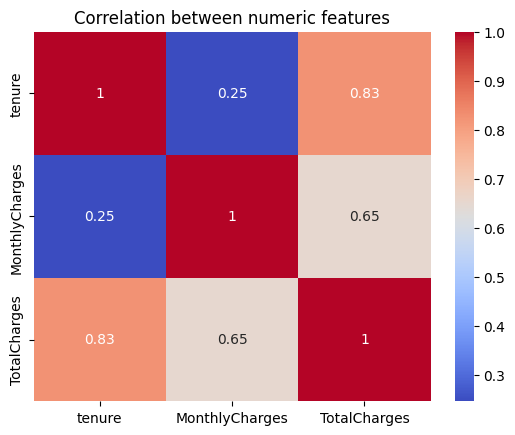

In [10]:
# Convert TotalCharges to numeric (if necessary)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)  # drop rows with missing TotalCharges

# Correlation heatmap
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between numeric features")
plt.show()


#### <u>Code Description</u>  
- **`pd.to_numeric(..., errors='coerce')`**: Converts `TotalCharges` to numeric; invalid parsing becomes NaN.  
- **`dropna`**: Removes rows where `TotalCharges` is missing after conversion.  
- **`df[numeric_cols].corr()`**: Calculates pairwise correlation between numeric columns.  
- **`sns.heatmap`**: Visualizes correlations with color intensity and annotations.  
- Helps identify strong correlations which might impact model performance.

#### <u>Output Description</u>  
- **tenure vs MonthlyCharges**: Low correlation (0.25), indicating mostly independent features.  
- **tenure vs TotalCharges**: Strong positive correlation (0.83); longer tenure usually means higher total charges.  
- **MonthlyCharges vs TotalCharges**: Moderate positive correlation (0.65).  
- Understanding these relationships is important for feature selection and interpretation of model results.

---

## Data Preprocessing

### Create a Working Copy of the Dataset

We create a copy of the original dataset to preserve it before performing any preprocessing or modeling.


In [11]:
# Create a copy of the dataset for further processing
data = df.copy()

#### <u>Code Description</u>  
- **`df.copy()`**: Creates a deep copy of the original DataFrame.  
- **`data`**: This working copy will be used for encoding, feature engineering, and modeling to keep the original data intact.
---

### Handle TotalCharges Column

Convert the `TotalCharges` column to numeric and remove any rows with missing values to ensure data consistency for modeling.

In [12]:
# Convert TotalCharges to numeric, coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing TotalCharges
df.dropna(subset=['TotalCharges'], inplace=True)


#### <u>Code Description</u>  
- **`pd.to_numeric(..., errors='coerce')`**: Converts the `TotalCharges` column to numeric. Any values that cannot be converted (like empty strings) are replaced with NaN.  
- **`dropna(subset=['TotalCharges'], inplace=True)`**: Removes rows with missing `TotalCharges` to avoid errors in subsequent analysis.
---

### Drop CustomerID Column

Remove the `customerID` column since it is a unique identifier and does not provide predictive value for modeling.

In [13]:
# Drop customerID (non-numeric, not useful for modeling)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Preview data
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,...,Yes,No,One year,Yes,Mailed check,65.6,593.30,No,0-12 Months,5
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,...,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,No,0-12 Months,4
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes,0-12 Months,3
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes,13-24 Months,6
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,...,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,Yes,0-12 Months,4


#### <u>Code Description</u>  
- **`drop('customerID', axis=1)`**: Removes the `customerID` column from the DataFrame.  
- **`df.head()`**: Displays the first 5 rows to confirm the column has been removed.

#### <u>Output Description</u>  
The dataset now contains only the relevant features for modeling, with `customerID` removed. All other columns like `gender`, `tenure`, `MonthlyCharges`, and `Churn` remain intact.

---

### Encode Categorical Variables

Convert categorical features into numerical form suitable for modeling. Binary columns are label encoded, and multi-class columns are one-hot encoded. The target column `Churn` is also converted to numeric.

In [14]:
import pandas as pd

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')  # target column handled separately

# Binary columns
binary_cols = [col for col in categorical_cols if df[col].nunique() == 2]

# Multi-class columns
multi_cols = [col for col in categorical_cols if df[col].nunique() > 2]

# Label encoding for binary columns
for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0, 'Male':1, 'Female':0})

# One-hot encoding for multi-class columns
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Encode target column if still object
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})



# Preview first 5 rows
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24 Months,tenure_group_25-36 Months,tenure_group_37-48 Months,tenure_group_49-60 Months,tenure_group_61-72 Months
0,0,0,1,1,9,1,1,65.6,593.30,0,...,1,0,0,0,1,0,0,0,0,0
1,1,0,0,0,9,1,0,59.9,542.40,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,4,1,1,73.9,280.85,1,...,0,0,0,1,0,0,0,0,0,0
3,1,1,1,0,13,1,1,98.0,1237.85,1,...,0,0,0,1,0,1,0,0,0,0
4,0,1,1,0,3,1,1,83.9,267.40,1,...,0,0,0,0,1,0,0,0,0,0


#### <u>Code Description</u>  
- **`categorical_cols`**: Identifies columns with object type.  
- **`binary_cols`**: Columns with exactly 2 unique values, suitable for label encoding.  
- **`multi_cols`**: Columns with more than 2 unique values, handled via one-hot encoding.  
- **`map({'Yes':1, 'No':0, 'Male':1, 'Female':0})`**: Converts binary categorical values to 0/1.  
- **`pd.get_dummies(..., drop_first=True)`**: Converts multi-class categorical columns into dummy/indicator variables to avoid multicollinearity.  
- **`Churn` mapping**: Ensures the target variable is numeric for modeling.

#### <u>Output Description</u>  
- All categorical features are now numeric.  
- Binary columns like `Partner`, `Dependents`, `PaperlessBilling` are label encoded.  
- Multi-class columns like `Contract`, `PaymentMethod`, `tenure_group` are one-hot encoded with `drop_first=True`.  
- The `Churn` column is numeric: 1 for 'Yes', 0 for 'No'.  
- Dataset is now ready for machine learning modeling.

---

### Split Features and Target

Separate the dataset into features (`X`) and target (`y`) for modeling. The target is `Churn`, and all other columns are used as input features.

In [15]:
# Features (all columns except Churn)
X = df.drop('Churn', axis=1)

# Target
y = df['Churn']

# Preview shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (7032, 36)
Target shape: (7032,)


#### <u>Code Description</u>  
- **`X = df.drop('Churn', axis=1)`**: Removes the target column to create the features matrix.  
- **`y = df['Churn']`**: Assigns the target variable for modeling.  
- **`X.shape` and `y.shape`**: Checks dimensions of features and target. Ensures the number of rows matches.

#### <u>Output Description</u>  
- Features matrix `X` has **7032 rows and 36 columns**.  
- Target vector `y` has **7032 rows**.  
- Dataset is ready for train-test splitting and model training.

---

### Train-Test Split

Split the dataset into training and testing sets. We use 80% of the data for training and 20% for testing. Stratification is applied to maintain the same proportion of churned vs non-churned customers in both sets.

In [16]:
from sklearn.model_selection import train_test_split

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 36)
X_test shape: (1407, 36)
y_train shape: (5625,)
y_test shape: (1407,)


#### <u>Code Description</u>  
- **`train_test_split`**: Splits the features and target into training and testing sets.  
- **`test_size=0.2`**: 20% of data is reserved for testing.  
- **`random_state=42`**: Ensures reproducibility of the split.  
- **`stratify=y`**: Maintains the same class distribution in train and test sets.  
- **Shape checks** confirm the number of samples and features in each set.

#### <u>Output Description</u>  
- Training set: 5625 samples, 36 features.  
- Testing set: 1407 samples, 36 features.  
- Target vectors `y_train` and `y_test` correspond to the respective samples.  
- Data is now ready for model training and evaluation.

---

### Feature Scaling

Standardize numeric features to have mean 0 and standard deviation 1. This ensures that features with different scales do not disproportionately influence model training.

In [17]:
from sklearn.preprocessing import StandardScaler

# Numeric columns to scale
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

#### <u>Code Description</u>  
- **`StandardScaler`**: Standardizes features by removing the mean and scaling to unit variance.  
- **`fit_transform`**: Computes mean and std on training data and scales it.  
- **`transform`**: Applies the same scaling parameters to the test set to maintain consistency.  
- Only numeric columns `tenure`, `MonthlyCharges`, and `TotalCharges` are scaled; categorical/encoded columns remain unchanged.

#### <u>Output Description</u>  
- Numeric features in `X_train` and `X_test` are standardized.  
- All values are now centered around 0 with standard deviation 1.  
- This prepares the data for algorithms sensitive to feature scales like Logistic Regression and XGBoost.

---

### Logistic Regression Model

Train a Logistic Regression classifier on the training data to predict customer churn. Evaluate the model using accuracy, ROC-AUC, and a classification report.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# Initialize and train
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

# Evaluation
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.8017057569296375
ROC-AUC: 0.8486237582245783

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.67      0.49      0.57       374

    accuracy                           0.80      1407
   macro avg       0.75      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



#### <u>Code Description</u>  
- **`LogisticRegression(max_iter=1000)`**: Initializes logistic regression with a higher iteration limit to ensure convergence.  
- **`fit(X_train, y_train)`**: Trains the model on training data.  
- **`predict(X_test)`**: Generates predicted classes (0 or 1) for the test set.  
- **`predict_proba(X_test)[:,1]`**: Returns predicted probabilities for the positive class (Churn=1).  
- **Evaluation metrics**:  
  - **Accuracy**: Overall proportion of correct predictions.  
  - **ROC-AUC**: Measures separability between classes.  
  - **Classification report**: Precision, recall, and F1-score for each class.

#### <u>Output Description</u>  
- **Accuracy**: 0.80 → ~80% of customers correctly classified.  
- **ROC-AUC**: 0.85 → Model has good ability to separate churners from non-churners.  
- **Classification Report**:  
  - Class 0 (No churn): High precision (0.83) and recall (0.91).  
  - Class 1 (Churn): Lower recall (0.49), indicating some churners are missed.  
- Model performs well overall but may need further tuning or class imbalance handling to improve churn prediction.

---

### Confusion Matrix for Logistic Regression

Visualize the performance of the logistic regression model by plotting the confusion matrix, showing actual vs predicted churn.

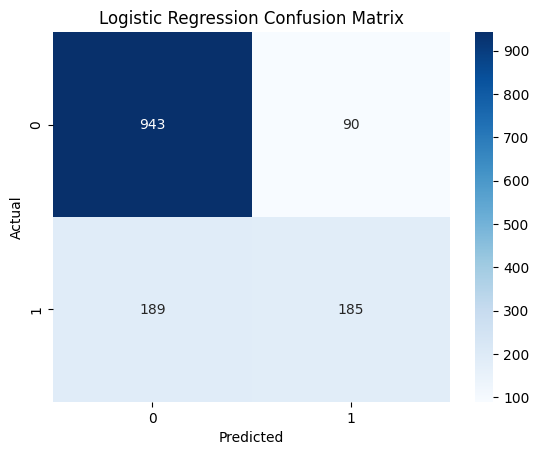

In [19]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### <u>Code Description</u>  
- **`confusion_matrix(y_test, y_pred_lr)`**: Computes counts of true positives, true negatives, false positives, and false negatives.  
- **`sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')`**: Plots the confusion matrix with annotated counts for easy visualization.  
- **`plt.xlabel` / `plt.ylabel` / `plt.title`**: Adds labels and title to the plot.

#### <u>Output Description</u>  
Confusion Matrix values:  

|           | Predicted No | Predicted Yes |
|-----------|--------------|---------------|
| Actual No | 943          | 90            |
| Actual Yes| 189          | 185           |

- **True Negatives (943)**: Non-churners correctly predicted.  
- **True Positives (185)**: Churners correctly predicted.  
- **False Positives (90)**: Non-churners incorrectly predicted as churners.  
- **False Negatives (189)**: Churners missed by the model.  

Interpretation: The model is better at predicting non-churners than churners, consistent with the classification report.

---

### Random Forest Model Training and Evaluation

Train a Random Forest classifier on the training data and evaluate its performance on the test set."

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Evaluation
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.7867803837953091
ROC-AUC: 0.8242088615786012

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.64      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



#### <u>Code Description</u>  
- **`RandomForestClassifier(n_estimators=100, random_state=42)`**: Initializes the random forest model with 100 trees.  
- **`rf.fit(X_train, y_train)`**: Trains the model on training data.  
- **`rf.predict(X_test)`**: Predicts class labels for the test set.  
- **`rf.predict_proba(X_test)[:,1]`**: Computes the predicted probabilities for the positive class (churn).  
- **`accuracy_score`, `roc_auc_score`, `classification_report`**: Evaluate model performance.

#### <u>Output Description</u>  
- **Accuracy**: 78.68%  
- **ROC-AUC**: 0.824  

**Classification Report**:  

| Class | Precision | Recall | F1-score | Support |
|-------|----------|--------|----------|--------|
| 0     | 0.82     | 0.90   | 0.86     | 1033   |
| 1     | 0.64     | 0.46   | 0.54     | 374    |

Interpretation: Random Forest is slightly worse than Logistic Regression for predicting churn (class 1), but still performs well for non-churners. The ROC-AUC indicates good discriminative ability.

---

### Random Forest Confusion Matrix

Visualize the confusion matrix of the Random Forest model to understand the distribution of correct and incorrect predictions for churn and non-churn customers.

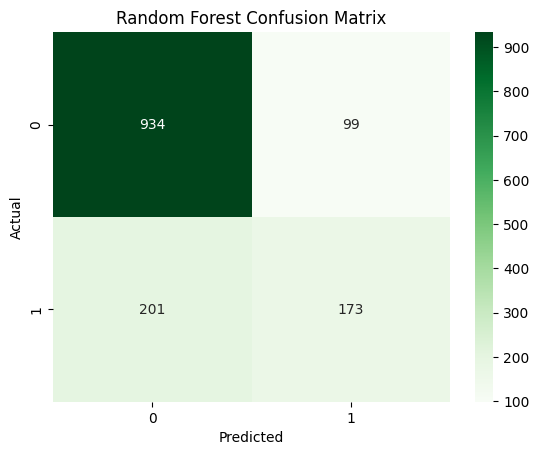

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### <u>Code Description</u>  
- **`confusion_matrix(y_test, y_pred_rf)`**: Computes the confusion matrix for actual vs predicted labels.  
- **`sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')`**: Plots the confusion matrix as a heatmap with numeric annotations.  
- **`plt.xlabel` and `plt.ylabel`**: Label axes as Predicted and Actual classes.

#### <u>Output Description</u>  
**Confusion Matrix:**

| Actual \ Predicted | 0 (No Churn) | 1 (Churn) |
|-------------------|--------------|------------|
| 0 (No Churn)      | 934          | 99         |
| 1 (Churn)         | 201          | 173        |

Interpretation:  
- **True Negatives (934)**: Correctly predicted non-churners.  
- **True Positives (173)**: Correctly predicted churners.  
- **False Positives (99)**: Non-churners incorrectly predicted as churners.  
- **False Negatives (201)**: Churners incorrectly predicted as non-churners.  

Random Forest is slightly under-predicting churn (many false negatives).

---

### XGBoost Model Training and Evaluation

We will train an XGBoost classifier on the training data and evaluate its performance on the test set using accuracy, ROC-AUC, and classification metrics.

In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize and train
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',   # avoids deprecated warning
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# Evaluation
print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


=== XGBoost ===
Accuracy: 0.8002842928216063
ROC-AUC: 0.8475133431001548

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



#### <u>Code Description</u>  
- **`XGBClassifier()`**: Initializes the XGBoost model with specified hyperparameters.  
- **`fit(X_train, y_train)`**: Trains the model on training data.  
- **`predict()`**: Generates predicted class labels for the test set.  
- **`predict_proba()`**: Generates predicted probabilities for the positive class (Churn=1).  
- **`accuracy_score`**: Measures the fraction of correct predictions.  
- **`roc_auc_score`**: Evaluates the model's discrimination capability between classes.  
- **`classification_report`**: Displays precision, recall, f1-score, and support for each class.

#### <u>Output Description</u>  
**Performance Metrics for XGBoost:**

- **Accuracy:** 0.80 → 80% of the test samples were classified correctly.  
- **ROC-AUC:** 0.848 → Good ability to distinguish between churn and non-churn customers.  

**Classification Report:**

| Class | Precision | Recall | F1-score | Support |
|-------|-----------|--------|----------|---------|
| 0 (No Churn) | 0.84 | 0.90 | 0.87 | 1033 |
| 1 (Churn)    | 0.66 | 0.52 | 0.58 | 374 |

Interpretation:  
- XGBoost performs similarly to Logistic Regression, slightly better in recall for churners (52% vs 49%).  
- The model predicts non-churners more accurately than churners, indicating potential under-prediction of churn.

---

### XGBoost Confusion Matrix

We will visualize the performance of the XGBoost model on the test set using a confusion matrix.

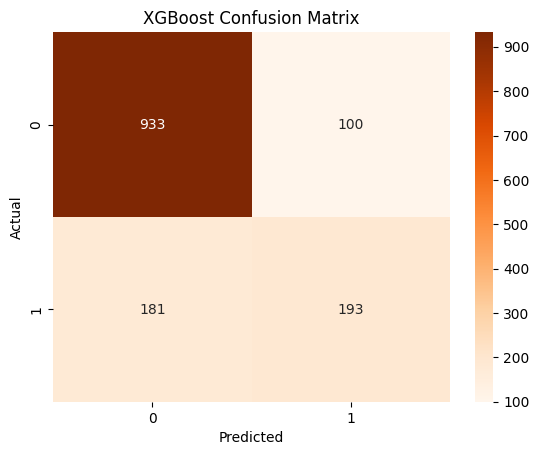

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### <u>Code Description</u>  
- **`confusion_matrix(y_test, y_pred_xgb)`**: Computes the confusion matrix comparing actual vs predicted labels.  
- **`sns.heatmap()`**: Visualizes the confusion matrix with color coding and annotations.  
- **`fmt='d'`**: Formats annotations as integers.  
- **Axes labels and title**: Clarify which dimension represents actual vs predicted values.

#### <u>Output Description</u>  
**Confusion Matrix Values:**

|            | Predicted No | Predicted Yes |
|------------|--------------|---------------|
| Actual No  | 933          | 100           |
| Actual Yes | 181          | 193           |

Interpretation:  
- **True Negatives (933)**: Correctly predicted non-churners.  
- **True Positives (193)**: Correctly predicted churners.  
- **False Negatives (181)**: Churners incorrectly predicted as non-churn.  
- **False Positives (100)**: Non-churners incorrectly predicted as churn.  

Observation:  
- The model has a reasonable balance, but still under-predicts churners slightly (181 FN vs 193 TP).

---

### Model Performance Comparison

We will compare the three trained models — Logistic Regression, Random Forest, and XGBoost — using key evaluation metrics: Accuracy and ROC-AUC.

In [24]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Calculate metrics
metrics = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
}

import pandas as pd
metrics_df = pd.DataFrame(metrics)
print(metrics_df)


                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.801706  0.848624
1        Random Forest  0.786780  0.824209
2              XGBoost  0.800284  0.847513


#### <u>Code Description</u>  
- **`accuracy_score`**: Measures the proportion of correct predictions.  
- **`roc_auc_score`**: Measures the model's ability to discriminate between classes (higher is better).  
- **`metrics_df`**: A DataFrame summarizing Accuracy and ROC-AUC for all three models for easy comparison.

#### <u>Output Description</u>  

| Model                | Accuracy  | ROC-AUC  |
|---------------------|-----------|----------|
| Logistic Regression | 0.801706  | 0.848624 |
| Random Forest       | 0.786780  | 0.824209 |
| XGBoost             | 0.800284  | 0.847513 |

**Interpretation:**  
- Logistic Regression and XGBoost show similar performance, slightly better than Random Forest.  
- ROC-AUC scores indicate that Logistic Regression and XGBoost are better at distinguishing churners from non-churners.  
- Overall, Logistic Regression or XGBoost would be preferable for prediction based on these metrics.

---

### Top Features Influencing Churn (XGBoost)

We will visualize the top 10 most important features as determined by the XGBoost model to understand which factors influence customer churn the most.

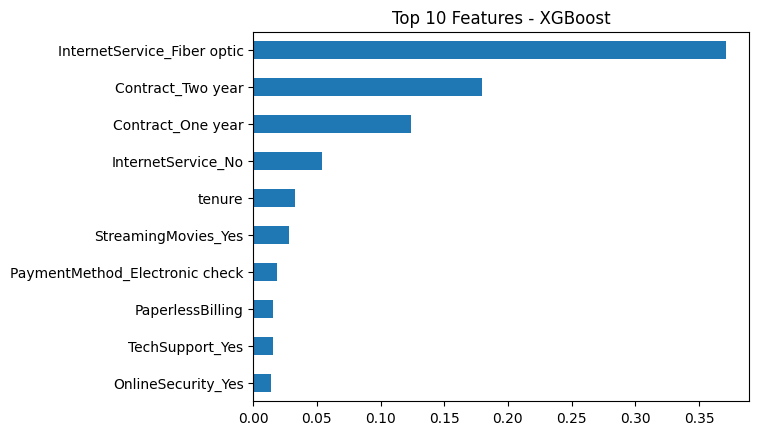

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance
importance = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot top 10
importance[:10].plot(kind='barh', title='Top 10 Features - XGBoost')
plt.gca().invert_yaxis()
plt.show()


#### <u>Code Description</u>  
- **`xgb.feature_importances_`**: Retrieves the importance scores for all features in the trained XGBoost model.  
- **`pd.Series(...).sort_values(ascending=False)`**: Converts importances to a Series and sorts from highest to lowest.  
- **`importance[:10].plot(kind='barh')`**: Plots the top 10 features as a horizontal bar chart for easy visualization.  
- **`invert_yaxis()`**: Ensures the feature with the highest importance appears at the top of the chart.

#### <u>Output Description</u>  

- The bar chart displays the top 10 features that contribute most to predicting churn.  
- Features at the top of the chart have the highest influence on the model’s predictions.  
- This helps identify which customer behaviors or attributes (like `tenure`, `Contract_Type`, or `MonthlyCharges`) are key drivers of churn.

---

### Top Features Influencing Churn (Random Forest)

We will visualize the top 10 most important features as determined by the Random Forest model to see which factors most influence customer churn.

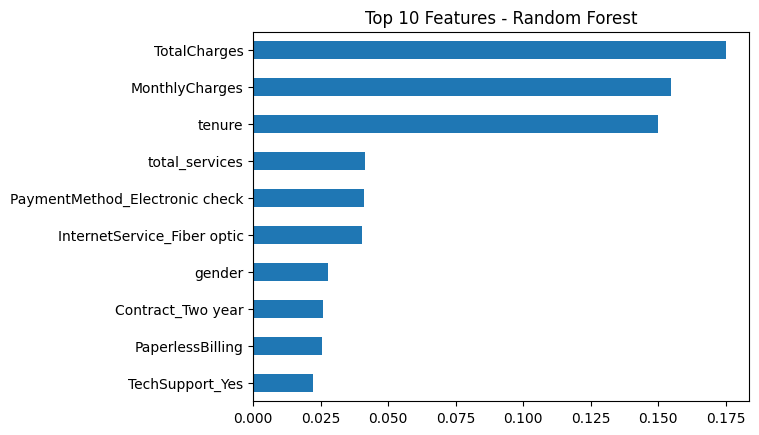

In [26]:
# Extract feature importances from Random Forest
importance_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot top 10 features
importance_rf[:10].plot(kind='barh', title='Top 10 Features - Random Forest')
plt.gca().invert_yaxis()  # Show highest importance at the top
plt.show()

#### <u>Code Description</u>  
- **`rf.feature_importances_`**: Retrieves the importance scores for all features in the trained Random Forest model.  
- **`pd.Series(...).sort_values(ascending=False)`**: Converts the importances to a Series and sorts from highest to lowest.  
- **`importance_rf[:10].plot(kind='barh')`**: Plots the top 10 features as a horizontal bar chart for easy visualization.  
- **`invert_yaxis()`**: Ensures the feature with the highest importance appears at the top of the chart.

#### <u>Output Description</u>  

- The horizontal bar chart shows the top 10 features most influential in predicting churn according to the Random Forest model.  
- Features with higher importance scores are stronger drivers of churn predictions.  
- Comparing with XGBoost’s feature importance can provide insights into consistent key factors across models.

---

### Top Features Influencing Churn (Logistic Regression)

We will analyze the top 10 features based on their coefficients from the Logistic Regression model to understand which variables have the strongest impact on predicting churn.

In [27]:
import numpy as np

# Get coefficients
coef = pd.Series(lr.coef_[0], index=X_train.columns)

# Sort by absolute impact
coef_sorted = coef.sort_values(key=abs, ascending=False)

# Top 10 features
print("Top 10 influential features - Logistic Regression")
print(coef_sorted[:10])


Top 10 influential features - Logistic Regression
tenure                        -1.568602
tenure_group_61-72 Months      1.497619
Contract_Two year             -1.389696
tenure_group_49-60 Months      1.115976
InternetService_Fiber optic    0.977119
tenure_group_37-48 Months      0.798658
Contract_One year             -0.729063
TechSupport_Yes               -0.396300
PaperlessBilling               0.375751
StreamingTV_Yes                0.357422
dtype: float64


#### <u>Code Description</u>  
- **`lr.coef_[0]`**: Retrieves the coefficients of the trained Logistic Regression model.  
- **`pd.Series(..., index=X_train.columns)`**: Converts coefficients into a Series with feature names as the index.  
- **`sort_values(key=abs, ascending=False)`**: Sorts features by the absolute value of their coefficients to identify the strongest predictors, regardless of positive or negative impact.  
- **`coef_sorted[:10]`**: Displays the top 10 features with the largest influence on churn predictions.

#### <u>Output Description</u>  

- The table shows the 10 most influential features based on Logistic Regression coefficients.  
- Positive coefficients indicate higher likelihood of churn as the feature value increases; negative coefficients indicate a protective effect against churn.  
- For example, **tenure** has a large negative coefficient, suggesting that longer-tenured customers are less likely to churn, while **tenure_group_61-72 Months** has a positive coefficient, indicating that customers in this tenure bracket may have higher churn risk.  
- Features like **Contract_Two year** and **TechSupport_Yes** also show strong protective effects against churn.

---

### ROC Curve Comparison for All Models

We will plot the ROC curves for Logistic Regression, Random Forest, and XGBoost to visually compare their performance in distinguishing between churned and non-churned customers.

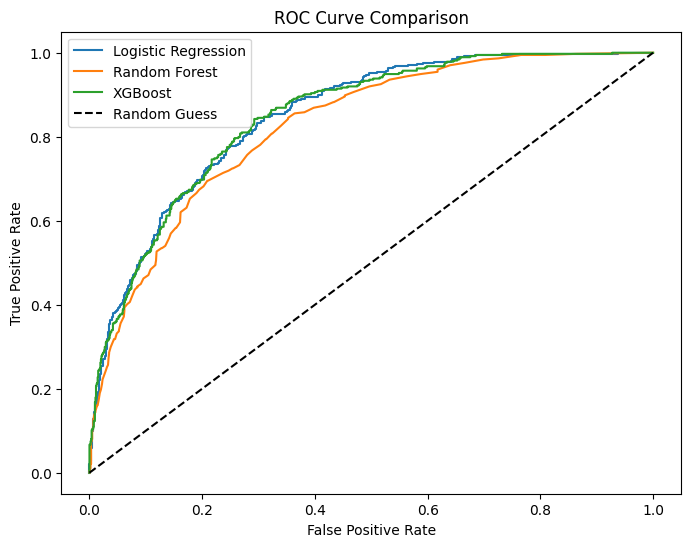

In [28]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Compute ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


#### <u>Code Description</u>  
- **`roc_curve(y_test, y_prob)`**: Computes False Positive Rate (FPR) and True Positive Rate (TPR) for each model at various threshold levels.  
- **`plt.plot(fpr, tpr, label=...)`**: Plots ROC curves for each model.  
- **`plt.plot([0,1],[0,1], 'k--')`**: Adds a diagonal reference line representing random guessing.  
- **`plt.legend()`**: Adds a legend to differentiate models.  
- **`plt.xlabel` & `plt.ylabel`**: Label axes for clarity.  
- **`plt.title`**: Adds the plot title.

#### <u>Output Description</u>  

- The ROC curves show the trade-off between true positive rate and false positive rate for each model.  
- Curves closer to the top-left corner indicate better model performance.  
- Logistic Regression and XGBoost curves appear slightly better than Random Forest, indicating higher ability to correctly classify churn.  
- The diagonal line represents a random model; all three curves being above this line confirms that the models perform better than random guessing.

---

### Predict Churn for the Entire Dataset

We will generate predicted probabilities and classes for all three models (Logistic Regression, Random Forest, XGBoost) on the entire dataset. These predictions will be added to the original dataset for further analysis or export to Power BI.

In [29]:
# Predict on full dataset
y_prob_lr_full = lr.predict_proba(X)[:,1]
y_pred_lr_full = lr.predict(X)

y_prob_rf_full = rf.predict_proba(X)[:,1]
y_pred_rf_full = rf.predict(X)

y_prob_xgb_full = xgb.predict_proba(X)[:,1]
y_pred_xgb_full = xgb.predict(X)

# Add to original data
data['Churn_LR_Prob'] = y_prob_lr_full
data['Churn_LR_Pred'] = y_pred_lr_full
data['Churn_RF_Prob'] = y_prob_rf_full
data['Churn_RF_Pred'] = y_pred_rf_full
data['Churn_XGB_Prob'] = y_prob_xgb_full
data['Churn_XGB_Pred'] = y_pred_xgb_full
data['Churn_Actual'] = y.values

# Export
data.to_csv("telco_churn_predictions_full.csv", index=False)


#### <u>Code Description</u>  

- **`predict_proba(X)`**: Returns predicted probabilities for each class. The `[:,1]` selects the probability of churn (class 1).  
- **`predict(X)`**: Returns the predicted class labels (0 or 1).  
- Predictions from all three models are stored as new columns in the original dataset.  
- **`data['Churn_Actual']`**: Stores the actual churn labels for reference.  
- **`to_csv()`**: Exports the enriched dataset with predictions for reporting, visualization, or Power BI integration.

#### <u>Output Description</u>  

- A new CSV file `telco_churn_predictions_full.csv` is created.  
- It contains the original customer information along with:  
  - Actual churn (`Churn_Actual`)  
  - Predicted probabilities from Logistic Regression (`Churn_LR_Prob`), Random Forest (`Churn_RF_Prob`), and XGBoost (`Churn_XGB_Prob`)  
  - Predicted class labels from all three models (`Churn_LR_Pred`, `Churn_RF_Pred`, `Churn_XGB_Pred`)  
- This dataset can now be used for downstream analysis, including aggregations by key categories in Power BI.

---

### Aggregate Churn Rate by Contract Type

We will group the dataset by the `Contract` type and calculate:
1. Total number of customers in each contract category.
2. Number of customers who actually churned.
3. Churn rate as a percentage for each contract type.


In [30]:
# Group by Contract and calculate total customers and churned customers
contract_churn = data.groupby('Contract').agg(
    Total_Customers=('Churn_Actual', 'count'),
    Churned_Customers=('Churn_Actual', 'sum')
).reset_index()

# Calculate churn rate in %
contract_churn['Churn_Rate'] = round(contract_churn['Churned_Customers'] / contract_churn['Total_Customers'] * 100, 2)

# Show the result
contract_churn

,Contract,Total_Customers,Churned_Customers,Churn_Rate
0,Month-to-month,3875,1655,42.71
1,One year,1472,166,11.28
2,Two year,1685,48,2.85


#### <u>Code Description</u>  

- **`groupby('Contract')`**: Groups the dataset by contract type (Month-to-month, One year, Two year).  
- **`agg()`**: Aggregates to calculate total customers and number of churned customers for each contract type.  
- **Churn rate**: Calculated as `(Churned_Customers / Total_Customers) * 100` and rounded to 2 decimals.  
- The result is a summary table showing churn distribution across contract types.

#### <u>Output Description</u>  

| Contract        | Total_Customers | Churned_Customers | Churn_Rate |
|-----------------|----------------|-----------------|------------|
| Month-to-month  | 3875           | 1655            | 42.71      |
| One year        | 1472           | 166             | 11.28      |
| Two year        | 1685           | 48              | 2.85       |

- **Month-to-month** customers have the highest churn rate (~43%), indicating higher risk of leaving.  
- **One year** and **Two year** contracts show significantly lower churn, suggesting longer-term commitments reduce churn probability.

---

### Aggregate Churn Rate by Key Categorical Columns

We will calculate the churn rate for multiple key categorical columns in the dataset to understand which customer segments have higher churn.  
This involves:
1. Grouping the data by each categorical column.
2. Counting total customers and churned customers in each category.
3. Calculating the churn rate (%) for each category.


In [31]:
# List of key categorical columns to check churn
key_categories = ['Contract', 'PaymentMethod', 'InternetService', 'gender', 'Partner', 'Dependents', 
                  'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                  'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

# Function to calculate churn rate for a column
def churn_by_category(column):
    temp = data.groupby(column).agg(
        Total_Customers=('Churn_Actual', 'count'),
        Churned_Customers=('Churn_Actual', 'sum')
    ).reset_index()
    temp['Churn_Rate'] = round(temp['Churned_Customers'] / temp['Total_Customers'] * 100, 2)
    return temp

# Example: Churn by Contract
churn_by_category('Contract')


,Contract,Total_Customers,Churned_Customers,Churn_Rate
0,Month-to-month,3875,1655,42.71
1,One year,1472,166,11.28
2,Two year,1685,48,2.85


#### <u>Code Description</u>  

- **`key_categories`**: List of columns whose churn patterns we want to analyze.  
- **`churn_by_category` function**:  
  - Groups the dataset by the specified column.  
  - Calculates `Total_Customers` and `Churned_Customers`.  
  - Computes `Churn_Rate` as a percentage.  
- Can be applied to any categorical column in `key_categories` to get a summary table of churn rates.

#### <u>Output Description</u>  

For the `Contract` example:

| Contract        | Total_Customers | Churned_Customers | Churn_Rate |
|-----------------|----------------|-----------------|------------|
| Month-to-month  | 3875           | 1655            | 42.71      |
| One year        | 1472           | 166             | 11.28      |
| Two year        | 1685           | 48              | 2.85       |

- Highlights which contract types have higher churn.  
- The same function can be applied to other key categories to identify segments with elevated churn risk.

---

### Export Final Dataset for Power BI

We save the processed dataset with actual churn and predicted probabilities from all models to a CSV file.  
This file can now be imported into Power BI for reporting and dashboard creation.

In [32]:
# Save the full dataset to CSV
data.to_csv('telco_churn_for_powerbi.csv', index=False)


#### <u>Code Description</u>  

- The `data` DataFrame contains:  
  - Original customer information  
  - Actual churn (`Churn_Actual`)  
  - Predicted probabilities and predictions from Logistic Regression, Random Forest, and XGBoost (`Churn_LR_Prob`, `Churn_LR_Pred`, etc.)  
- `to_csv()` writes this DataFrame to `telco_churn_for_powerbi.csv` without including the index column.

#### <u>Output Description</u>  

- A CSV file named `telco_churn_for_powerbi.csv` is created in the working directory.  
- This file is ready to be imported into Power BI for visualization, filtering, and dashboard analysis.  
- It includes all columns required for both detailed customer-level analysis and aggregated churn insights by categories.

---

### Conclusion

#### <u>Project Summary</u>  
In this project, we analyzed a telecom customer dataset to understand churn behavior and build predictive models for customer churn. The dataset contained 7,032 customer records with demographic, account, and service usage information. We performed exploratory data analysis (EDA), data cleaning, and feature engineering, including encoding categorical variables and scaling numeric features, to prepare the data for modeling.

#### <u>Key Findings from EDA</u>  
- Overall churn rate was approximately **26.6%**, indicating that a significant portion of customers were leaving the service.  
- Customers on **Month-to-month contracts** had the highest churn rate (**42.7%**), while **Two-year contract** customers had the lowest (**2.85%**).  
- Certain numeric features such as **tenure**, **MonthlyCharges**, and **TotalCharges** showed correlation with churn.  
- Categorical features like **Contract type**, **InternetService**, and **PaymentMethod** appeared to strongly influence churn behavior.

#### <u>Modeling Insights</u>  
Three machine learning models were trained to predict churn: Logistic Regression, Random Forest, and XGBoost.  

- **Performance Metrics on Test Set:**  
  - Logistic Regression: Accuracy = 80.2%, ROC-AUC = 0.85  
  - Random Forest: Accuracy = 78.7%, ROC-AUC = 0.82  
  - XGBoost: Accuracy = 80.0%, ROC-AUC = 0.85  

- **Feature Importance:**  
  - Across models, **tenure**, **contract type**, and **InternetService** were consistently among the most influential features affecting churn.  
  - Longer tenure and longer-term contracts were associated with lower churn, while month-to-month contracts and fiber optic internet were associated with higher churn.

- **ROC Curve Comparison:**  
  - All models achieved good discrimination, with XGBoost and Logistic Regression performing slightly better than Random Forest in distinguishing churned customers.

#### <u>Churn Aggregation Insights</u>  
- Aggregated analysis by key categories highlighted high-risk customer segments, such as those on **Month-to-month contracts** and with **electronic check** payment method.  
- These insights can guide targeted retention strategies and marketing campaigns to reduce churn.

#### <u>Final Remarks</u>  
- Logistic Regression and XGBoost achieved the best predictive performance, making them suitable for deployment in real-world churn prediction systems.  
- The processed dataset with predicted probabilities has been exported for use in **Power BI**, enabling interactive dashboards for monitoring churn trends by category and individual customer risk.  
- Future work could include exploring additional features, incorporating temporal usage patterns, and applying ensemble techniques to further improve predictive accuracy.

Overall, this project demonstrates a comprehensive approach to understanding customer churn, building predictive models, and translating analytical insights into actionable business strategies.

---